# Data Visualization — Seaborn
## Statistical Charts with Less Code
Seaborn = built on Matplotlib, adds statistical context automatically
Less code, more insight — heatmaps, boxplots, pairplots in one line

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("financials_clean2.csv")
df['Profit Margin %'] = round((df['Profit'] / df['Sales']) * 100, 2)

sns.set_theme(style="whitegrid")
print(df.shape)

(688, 29)


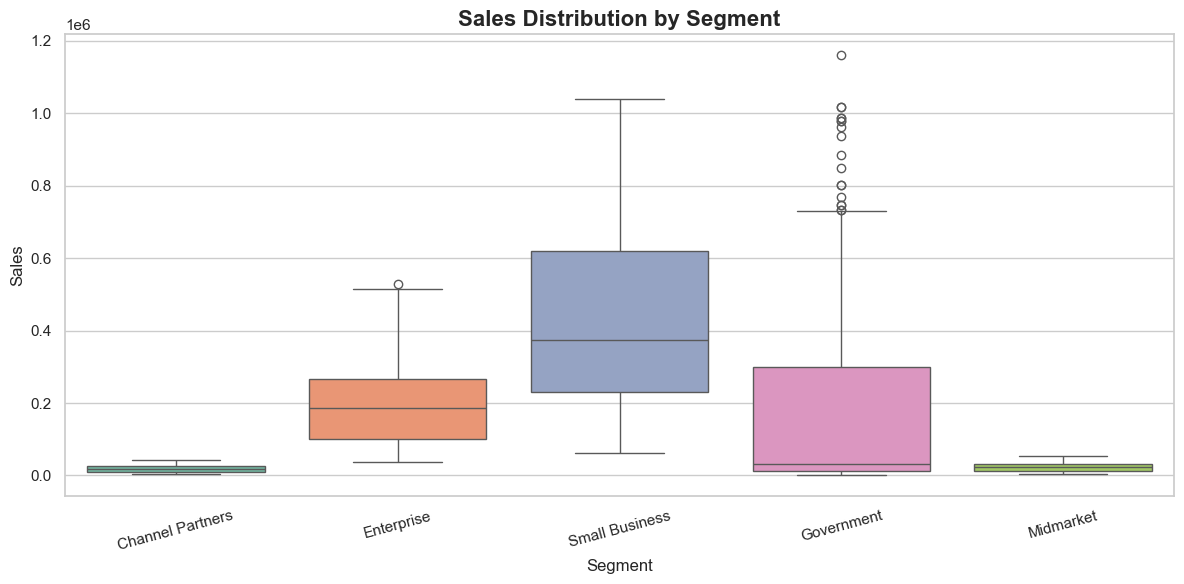

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Segment', y='Sales', hue='Segment', palette='Set2', legend=False, ax=ax)
ax.set_title('Sales Distribution by Segment', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

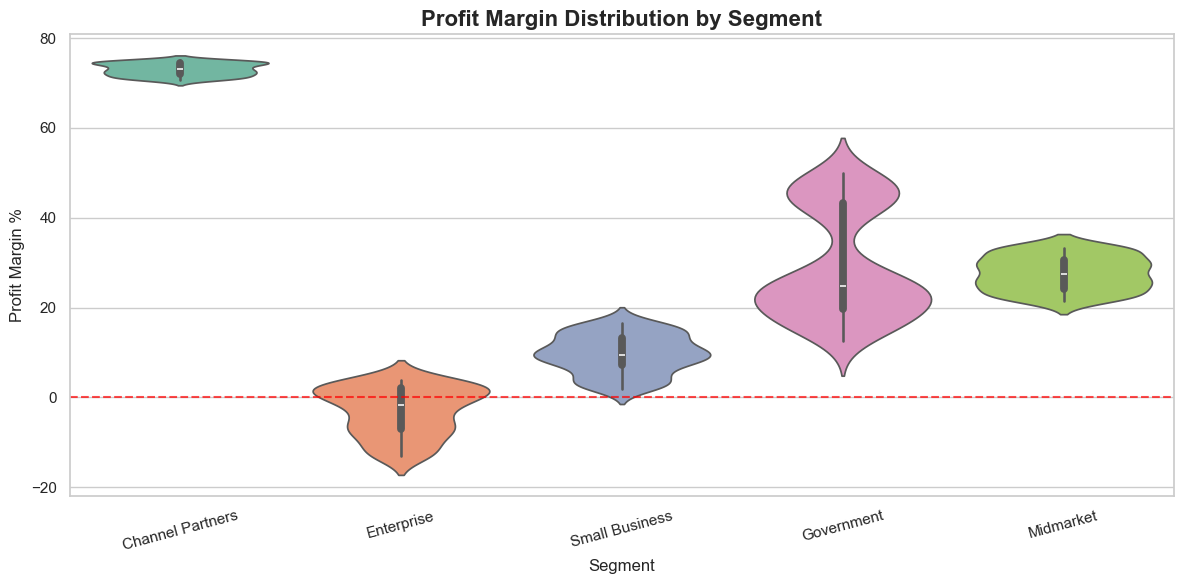

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df, x='Segment', y='Profit Margin %', 
               hue='Segment', palette='Set2', legend=False, ax=ax)
ax.set_title('Profit Margin Distribution by Segment', fontsize=16, fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

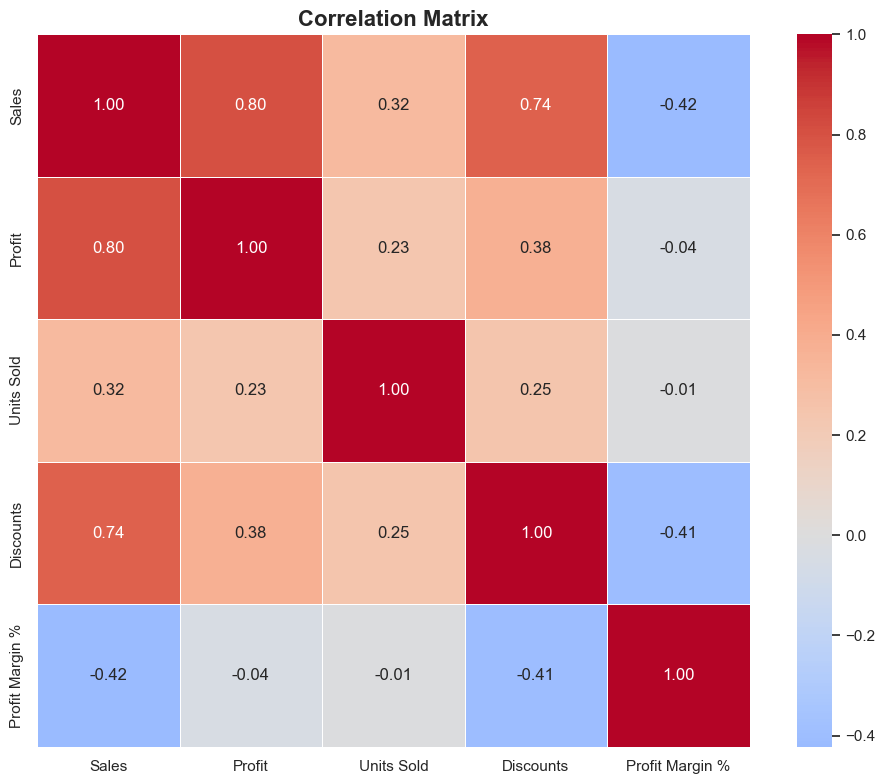

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[['Sales', 'Profit', 'Units Sold', 'Discounts', 'Profit Margin %']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

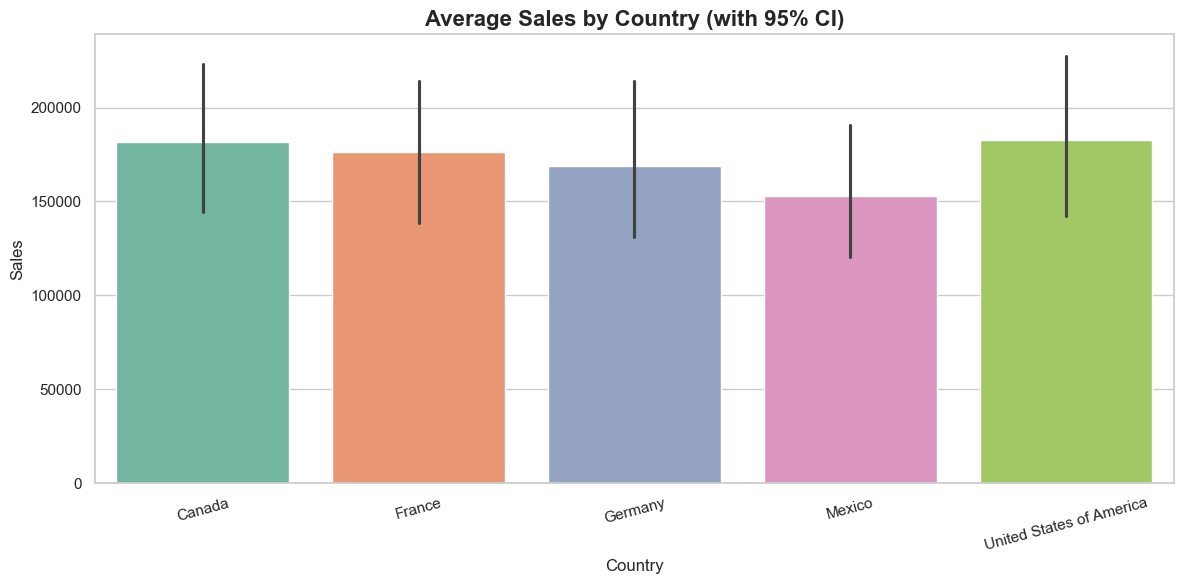

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df, x='Country', y='Sales', hue='Country',
            palette='Set2', estimator='mean', errorbar='ci', 
            legend=False, ax=ax)
ax.set_title('Average Sales by Country (with 95% CI)', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

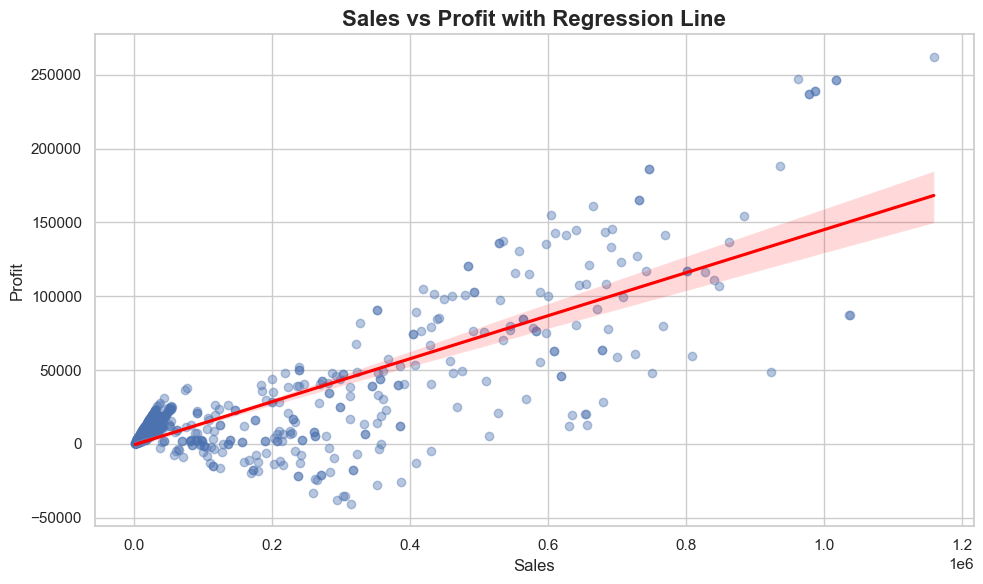

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df, x='Sales', y='Profit', 
            scatter_kws={'alpha': 0.4},
            line_kws={'color': 'red'}, ax=ax)
ax.set_title('Sales vs Profit with Regression Line', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

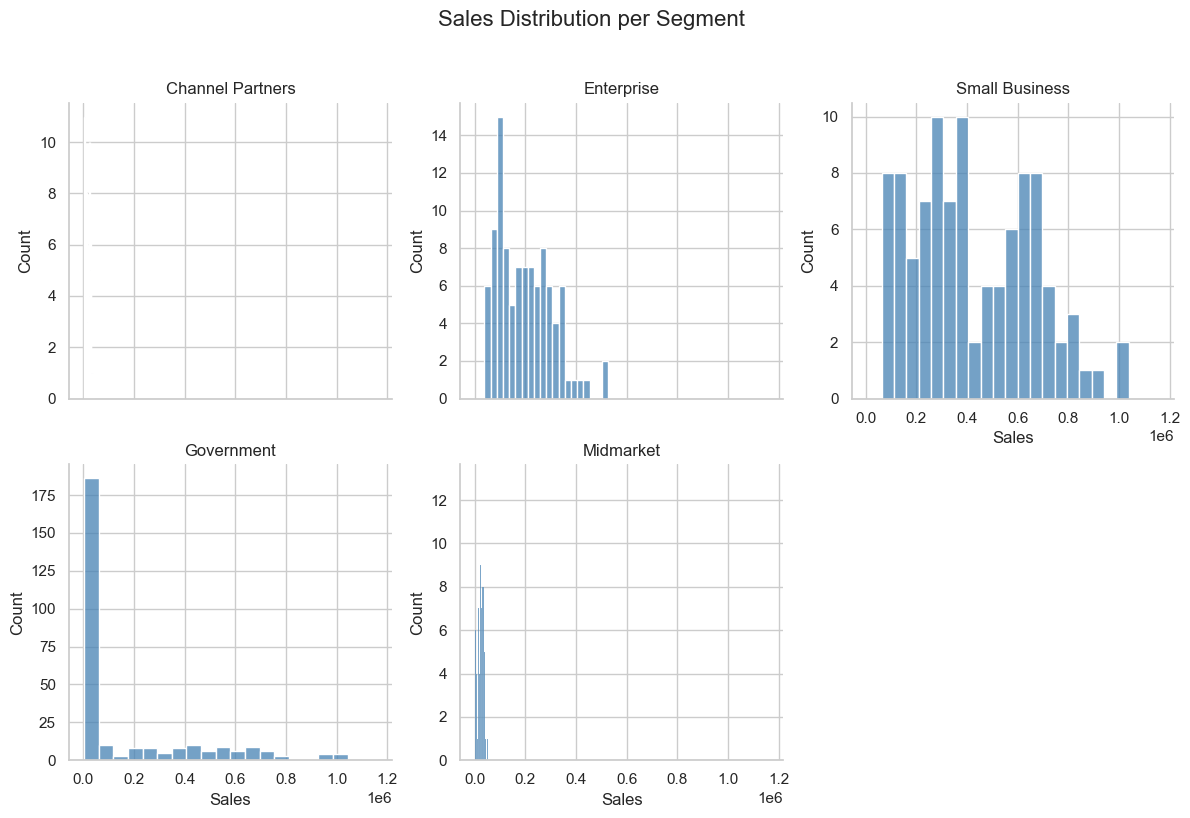

In [14]:
g = sns.FacetGrid(df, col='Segment', col_wrap=3, height=4, sharey=False)
g.map(sns.histplot, 'Sales', bins=20, color='steelblue')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Sales Distribution per Segment', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

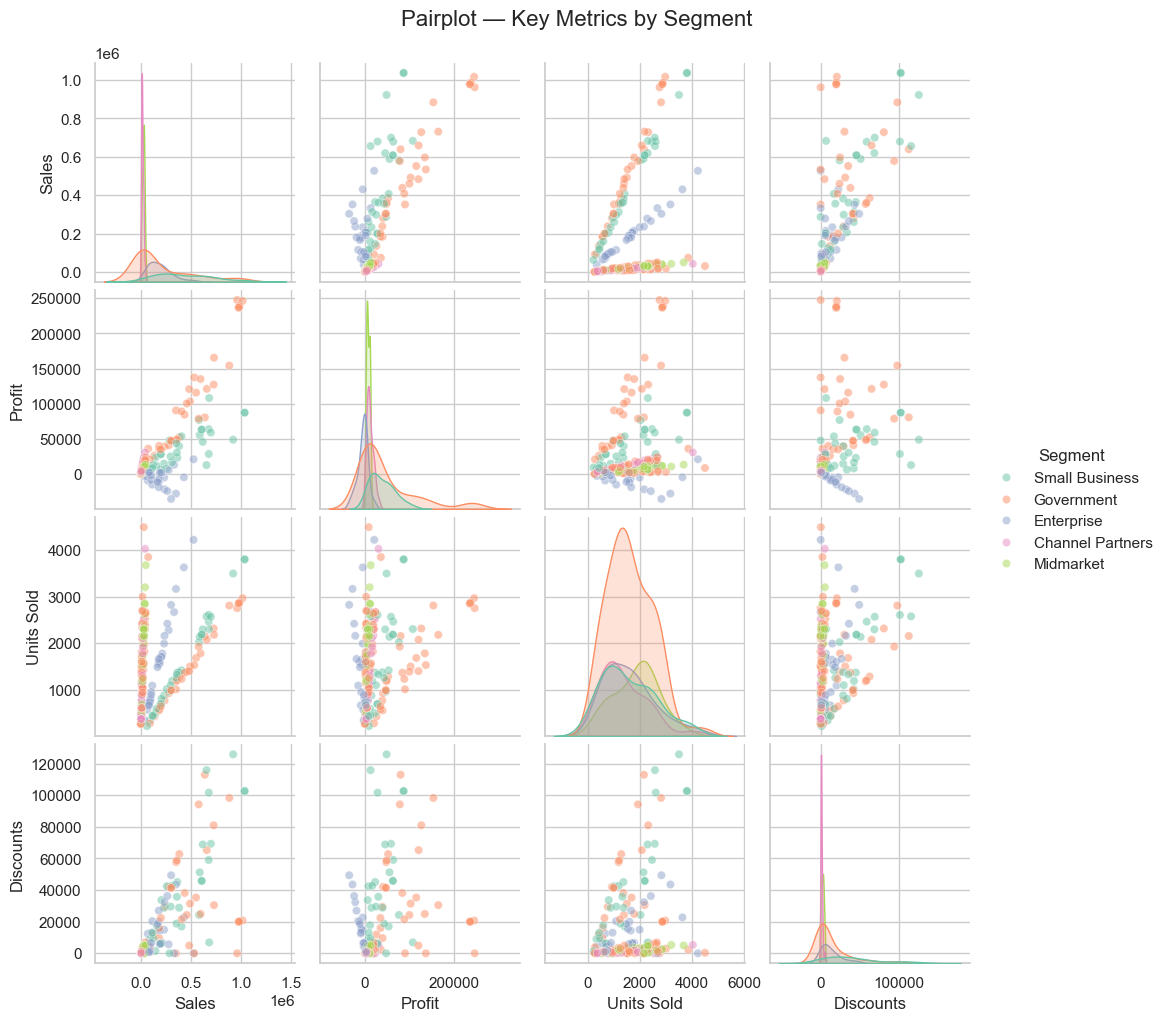

In [15]:
numeric_cols = df[['Sales', 'Profit', 'Units Sold', 'Discounts', 'Segment']].sample(200)
sns.pairplot(numeric_cols, hue='Segment', palette='Set2', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot — Key Metrics by Segment', y=1.02, fontsize=16)
plt.show()